# Question 1: (Chapter 4: Exercise 4.2)

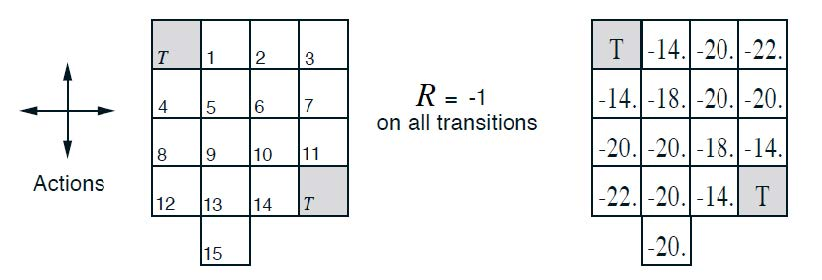

From Example 4.1, all non-terminal states have $R = -1$, $\gamma = 1$, and the policy is equiprobable ($\pi(a|s) = 1/4$), so the Bellman equation is just:

$$V_\pi(s) = -1 + \frac{1}{4} \sum_a V_\pi(s')$$

We'll need these values from the original gridworld: $V_\pi(12) = -22$, $V_\pi(13) = -20$, $V_\pi(14) = -14$.

---

### Case 1

State 15 sits in the corner — moving left goes to 12, up goes to 13, right goes to 14, and down just hits the wall so it stays at 15. Plugging into the Bellman equation:

$$V_\pi(15) = -1 + \frac{1}{4}\bigl[V_\pi(12) + V_\pi(13) + V_\pi(14) + V_\pi(15)\bigr]$$

$$= -1 + \frac{1}{4}[-22 - 20 - 14 + V_\pi(15)]$$

$$= -15 + \frac{1}{4}V_\pi(15)$$

Moving the $V_\pi(15)$ term over and solving: $\frac{3}{4}V_\pi(15) = -15$, so $V_\pi(15) = -20$.

---

### Case 2

Now state 13's `down` action goes to state 15 instead of bouncing back to 13. At first this seems like it would change things, but notice that we just found $V_\pi(15) = -20$, which is exactly the same as $V_\pi(13) = -20$. So from state 13's perspective, whether `down` leads to itself or to state 15 doesn't actually matter — the value on the other end is the same either way. Nothing needs to be recalculated.

So $V_\pi(15) = -20$ in both cases.

# This is Example 4.3. Gambler’s Problem from Sutton's book.

A gambler has the opportunity to make bets on the outcomes of a sequence of coin flips. 
If the coin comes up heads, he wins as many dollars as he has staked on that flip; 

if it is tails, he loses his stake. The game ends when the gambler wins by reaching his goal of $100, 
or loses by running out of money. 

On each flip, the gambler must decide what portion of his capital to stake, in integer numbers of dollars. 
This problem can be formulated as an undiscounted, episodic, finite MDP. 

The state is the gambler’s capital, s ∈ {1, 2, . . . , 99}.
The actions are stakes, a ∈ {0, 1, . . . , min(s, 100 − s)}. 
The reward is zero on all transitions except those on which the gambler reaches his goal, when it is +1.

The state-value function then gives the probability of winning from each state. A policy is a mapping from levels of capital to stakes. The optimal policy maximizes the probability of reaching the goal. Let p_h denote the probability of the coin coming up heads. If p_h is known, then the entire problem is known and it can be solved, for instance, by value iteration.


In [2]:
import numpy as np
import sys
import matplotlib.pyplot as plt
if "../" not in sys.path:
  sys.path.append("../") 


## Exercise 4.9 (programming)

Implement value iteration for the gambler’s problem and solve it for p_h = 0.25 and p_h = 0.55.



In [4]:
def value_iteration_for_gamblers(p_h, theta=0.0001, discount_factor=1.0):
    """
    Args:
        p_h: Probability of the coin coming up heads
    """
    GOAL = 100
    
    def one_step_lookahead(s, V, rewards):
        """
        Helper function to calculate the value for all action in a given state.
        
        Args:
            s: The gambler’s capital. Integer.
            V: The vector that contains values at each state. 
            rewards: The reward vector.
                        
        Returns:
            A vector containing the expected value of each action. 
            Its length equals to the number of actions.
        """
        
        max_stake = min(s, GOAL - s)

        # A[a] means the action-value of staking a dollars
        A = np.zeros(max_stake + 1)

        for a in range(1, max_stake + 1):
            win_state = s + a
            lose_state = s - a

            A[a] = (
                p_h * (rewards[win_state] + discount_factor * V[win_state])
                + (1 - p_h) * (rewards[lose_state] + discount_factor * V[lose_state])
            )
        
        return A
    
    # Initialize value function
    V = np.zeros(GOAL + 1)

    # Dummy terminal states:
    # V(0) = 0, V(100) = 1
    V[GOAL] = 1.0

    # Since we use V(100)=1, rewards can be zero everywhere
    rewards = np.zeros(GOAL + 1)

    # Value iteration
    while True:
        delta = 0

        for s in range(1, GOAL):
            old_v = V[s]

            A = one_step_lookahead(s, V, rewards)

            # exclude stake = 0
            V[s] = np.max(A[1:])

            delta = max(delta, abs(old_v - V[s]))

        if delta < theta:
            break

    # Extract optimal policy
    policy = np.zeros(GOAL + 1, dtype=int)

    for s in range(1, GOAL):
        A = one_step_lookahead(s, V, rewards)

        # exclude stake = 0
        # round helps handle numerical ties
        policy[s] = np.argmax(np.round(A[1:], 5)) + 1
    
    return policy, V

In [5]:
policy, v = value_iteration_for_gamblers(0.25)

print("Optimized Policy:")
print(policy)
print("")

print("Optimized Value Function:")
print(v)
print("")

Optimized Policy:
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 12 11 10  9 17 18  6  5  4  3  2
  1 25  1  2  3  4  5  6  7  8  9 10 11 12 12 11 10  9  8  7  6  5  4  3
  2  1 50  1  2  3  4  5  6  7  8  9 10 11 12 12 11 10  9  8  7  6  5  4
  3  2  1 25  1  2  3  4  5  6  7  8  9 10 11 12 12 11 10  9  8  7  6  5
  4  3  2  1  0]

Optimized Value Function:
[0.00000000e+00 7.24792480e-05 2.89916992e-04 6.95257448e-04
 1.16010383e-03 1.76906586e-03 2.78102979e-03 4.03504074e-03
 4.66214120e-03 5.59997559e-03 7.08471239e-03 9.03964043e-03
 1.11241192e-02 1.56793594e-02 1.61464431e-02 1.69517994e-02
 1.86512806e-02 1.98249817e-02 2.24047303e-02 2.73845196e-02
 2.83388495e-02 3.04937363e-02 3.61633897e-02 3.84953022e-02
 4.44964767e-02 6.25000000e-02 6.27174377e-02 6.33700779e-02
 6.45857723e-02 6.59966059e-02 6.78135343e-02 7.08430894e-02
 7.46098323e-02 7.64884604e-02 7.93035477e-02 8.37541372e-02
 8.96225423e-02 9.58723575e-02 1.09538078e-01 1.10939329e-01
 1.13360151e-01 1.18457374e-01 1.219

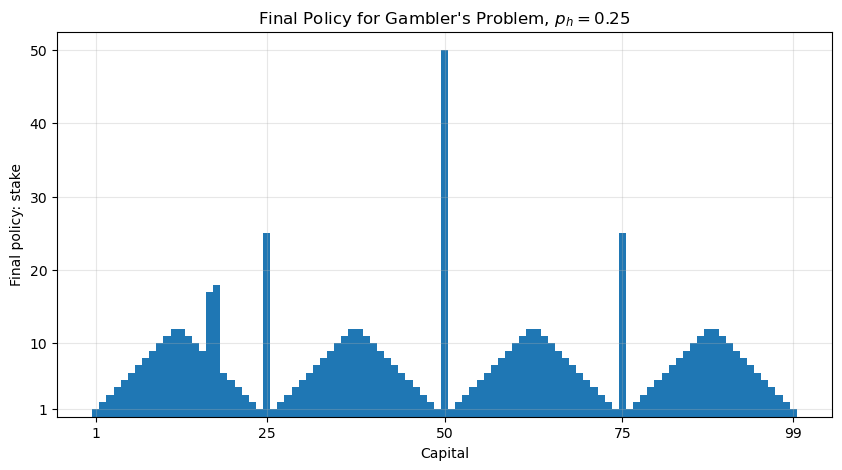

In [6]:
# Plotting Final Policy (action stake) vs State (Capital)

states = np.arange(1, 100)

plt.figure(figsize=(10, 5))
plt.bar(states, policy[1:100], width=1.0)

plt.xlabel("Capital")
plt.ylabel("Final policy: stake")
plt.title("Final Policy for Gambler's Problem, $p_h = 0.25$")

plt.xticks([1, 25, 50, 75, 99])
plt.yticks([1, 10, 20, 30, 40, 50])
plt.grid(True, alpha=0.3)

plt.show()

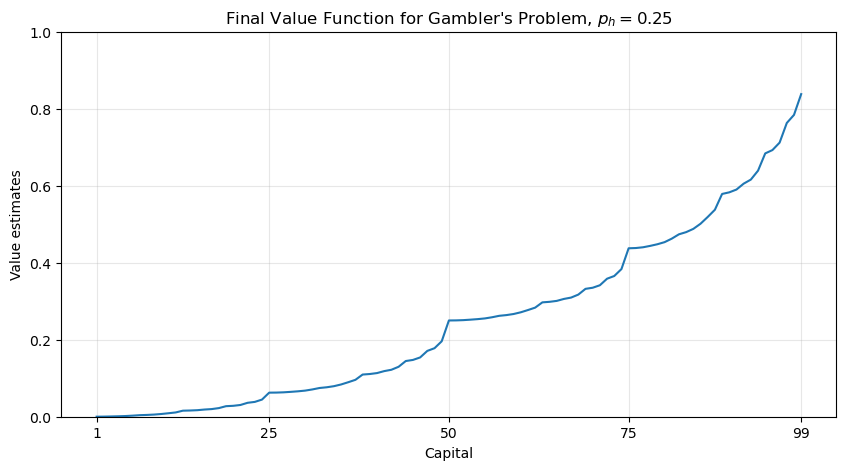

In [9]:
# Plotting Capital vs Final Policy

states = np.arange(1, 100)

plt.figure(figsize=(10, 5))
plt.plot(states, v[1:100])

plt.xlabel("Capital")
plt.ylabel("Value estimates")
plt.title("Final Value Function for Gambler's Problem, $p_h = 0.25$")

plt.xticks([1, 25, 50, 75, 99])
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)

plt.show()


# Question 3: (Chapter 5: Exercise 5.1)

**Why does the value function jump up for the last two rear rows**

The policy says stick at 20 or 21, so no more bust risk — the player just waits with a strong hand. States before that still require hitting, which can go wrong, so the value jumps sharply once you reach 20 or 21.

**Why does it drop off for the whole last row on the left??**

A dealer ace can count as 11, giving the dealer a strong starting total and a good chance of winning regardless of what the player holds. Other cards don't carry that flexibility, which is why the ace uniquely drags down the whole row.

**Why are the frontmost values higher in the upper diagrams than in the lower?**

A usable ace acts as a safety net when hitting — if the next card would cause a bust, the ace flips from 11 to 1. So at low player sums where the player keeps hitting, the bust risk is much lower, and the values are correspondingly higher.

# Question 4: (Chapter 6: Exercise 6.2)

Say I've driven home from my old office many times, so my estimate of travel time from the highway entrance onward is already pretty accurate — call it 25 minutes. Now I move to a new building with a new parking lot, but I still get on the highway at the same spot.

On my first trip from the new lot, it takes 6 minutes to reach the highway entrance. A TD update can immediately use that: $6 + V(\text{highway entrance}) = 31$ minutes, bootstrapping off the already-reliable highway estimate. Monte Carlo has to wait until I actually get home, and if there's unusual traffic that day, the total time is noisy — it ends up updating the new parking lot value based on a bad sample that has nothing to do with the part I'm still learning.

So TD is better here because it isolates the uncertainty to the new portion of the trip and reuses what's already well-learned. The same thing can happen in the original task whenever later states are already well-estimated — TD lets earlier states bootstrap off those, while Monte Carlo drags everything through the noise of the full episode.

# Question 5: (Chapter 6: Exercise 6.14)

The afterstate here is just the number of cars at each location after Jack moves them overnight, before the next day's rentals and returns happen. So from state $(i, j)$, moving $a$ cars deterministically gives afterstate $(i-a, j+a)$.

This speeds convergence because what happens next — the rentals and returns — only depends on how many cars are sitting at each location that morning, not on how they got there. Different $(s, a)$ pairs that happen to produce the same car distribution share the same afterstate value, so their experience gets pooled. Instead of learning redundant estimates for each combination, the value function only needs one estimate per post-move distribution.

# Question 6

In [10]:
import random
import math
from collections import deque, namedtuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)

## Define the task-oriented dialogue environment|

In [11]:
SLOTS = ["drink", "size", "sugar", "ice", "name"]
ACTIONS = [f"request_{slot}" for slot in SLOTS] + ["confirm_order"]
N_ACTIONS = len(ACTIONS)
MAX_TURNS = 10


class BobaOrderEnv:
    """
    User simulator for a boba tea ordering task.
    The user has a hidden goal (a full order) and answers
    whenever the bot asks about an unfilled slot.
    Episode ends when the bot confirms or runs out of turns.
    """

    def __init__(self, max_turns=MAX_TURNS, seed=SEED):
        self.rng = random.Random(seed)
        self.max_turns = max_turns

        # Small dataset I put together for this domain
        self.drinks = ["milk tea", "taro", "matcha", "brown sugar", "jasmine green"]
        self.sizes  = ["medium", "large"]           # boba places usually just have two
        self.sugars = ["0%", "25%", "50%", "100%"]  # sugar level is boba-specific
        self.ices   = ["no ice", "less ice", "regular ice"]
        self.names  = ["alex", "sam", "jordan", "taylor", "casey"]

        self.reset()

    def sample_goal(self):
        return {
            "drink": self.rng.choice(self.drinks),
            "size":  self.rng.choice(self.sizes),
            "sugar": self.rng.choice(self.sugars),
            "ice":   self.rng.choice(self.ices),
            "name":  self.rng.choice(self.names),
        }

    def reset(self):
        self.goal       = self.sample_goal()
        self.filled     = {slot: None for slot in SLOTS}
        self.turn       = 0
        self.last_action = None
        return self.state()

    def state(self):
        # Which slots are already filled (5 bits)
        filled_bits = np.array(
            [self.filled[slot] is not None for slot in SLOTS], dtype=np.float32
        )
        # One-hot of the last action taken (gives the agent memory of what it just did)
        last_action_oh = np.zeros(N_ACTIONS, dtype=np.float32)
        if self.last_action is not None:
            last_action_oh[self.last_action] = 1.0

        can_confirm   = np.array([filled_bits.all()], dtype=np.float32)
        turn_fraction = np.array([self.turn / self.max_turns], dtype=np.float32)

        return np.concatenate([filled_bits, last_action_oh, can_confirm, turn_fraction])

    def step(self, action_idx):
        self.turn += 1
        self.last_action = action_idx

        action  = ACTIONS[action_idx]
        done    = False
        success = False
        reward  = -1.0  # turn penalty — every wasted turn costs something

        if action.startswith("request_"):
            slot = action.replace("request_", "")
            bot_utterance = f"What {slot} would you like?"

            if self.filled[slot] is None:
                self.filled[slot] = self.goal[slot]
                reward += 1.0   # useful question
                user_utterance = f"{slot} = {self.goal[slot]}"
            else:
                reward -= 1.0   # already asked this — penalise repeating yourself
                user_utterance = f"I already told you my {slot}."

        else:
            bot_utterance = "Let me confirm your order."

            if all(self.filled[slot] == self.goal[slot] for slot in SLOTS):
                reward        = 20.0
                done          = True
                success       = True
                user_utterance = "Yes, that's right!"
            else:
                reward        = -10.0
                done          = True
                user_utterance = "That order is incomplete."

        if self.turn >= self.max_turns and not done:
            reward        = -10.0
            done          = True
            user_utterance = "Too many turns, giving up."

        info = {
            "success": success,
            "action":  action,
            "bot":     bot_utterance,
            "user":    user_utterance,
            "goal":    self.goal.copy(),
            "filled":  self.filled.copy(),
        }
        return self.state(), reward, done, info


env       = BobaOrderEnv()
STATE_DIM = len(env.state())

print("State dim :", STATE_DIM)
print("N actions :", N_ACTIONS)
print("Actions   :", ACTIONS)

State dim : 13
N actions : 6
Actions   : ['request_drink', 'request_size', 'request_sugar', 'request_ice', 'request_name', 'confirm_order']


## replay buffer, Q-network, optimisation step

In [13]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])


class ReplayBuffer:
    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)


class QNetwork(nn.Module):
    # I tried hidden_dim=128 first but it overfit and the success
    # rate was unstable. 64 units converged more smoothly.
    def __init__(self, state_dim, n_actions, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )

    def forward(self, x):
        return self.net(x)


def optimize_model(
    policy_net, target_net, optimizer, replay_buffer,
    batch_size=64, gamma=0.95, device="cpu"
):
    if len(replay_buffer) < batch_size:
        return None

    batch = replay_buffer.sample(batch_size)

    states      = torch.as_tensor(np.array(batch.state),      dtype=torch.float32, device=device)
    actions     = torch.as_tensor(batch.action,                dtype=torch.long,    device=device).unsqueeze(1)
    rewards     = torch.as_tensor(batch.reward,                dtype=torch.float32, device=device).unsqueeze(1)
    next_states = torch.as_tensor(np.array(batch.next_state),  dtype=torch.float32, device=device)
    dones       = torch.as_tensor(batch.done,                  dtype=torch.float32, device=device).unsqueeze(1)

    q_values = policy_net(states).gather(1, actions)

    with torch.no_grad():
        # Double DQN: policy_net picks the action, target_net scores it.
        # This reduces overestimation compared to vanilla DQN.
        next_actions  = policy_net(next_states).argmax(dim=1, keepdim=True)
        next_q_values = target_net(next_states).gather(1, next_actions)
        targets       = rewards + gamma * (1.0 - dones) * next_q_values

    loss = F.smooth_l1_loss(q_values, targets)  # Huber loss — less sensitive to outlier rewards

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=5.0)
    optimizer.step()

    return loss.item()

## training loop

In [14]:


def train_dqn(num_episodes=1000, seed=SEED, device="cpu"):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = BobaOrderEnv(seed=seed)

    policy_net = QNetwork(STATE_DIM, N_ACTIONS).to(device)
    target_net = QNetwork(STATE_DIM, N_ACTIONS).to(device)
    target_net.load_state_dict(policy_net.state_dict())

    # Adam worked better than SGD here — the reward scale is quite variable
    optimizer = optim.Adam(policy_net.parameters(), lr=1e-3)
    replay_buffer = ReplayBuffer()

    # Epsilon decay: starts fully random, anneals to 5% over ~350 episodes.
    # I tried 500 but the agent was exploring too long before learning anything useful.
    epsilon_start = 1.0
    epsilon_end   = 0.05
    epsilon_decay = 350

    rewards   = []
    successes = []
    losses    = []

    global_step = 0

    for episode in range(1, num_episodes + 1):
        state           = env.reset()
        episode_reward  = 0.0
        episode_success = False

        for turn in range(MAX_TURNS):
            epsilon = epsilon_end + (epsilon_start - epsilon_end) * math.exp(-episode / epsilon_decay)

            if random.random() < epsilon:
                action = random.randrange(N_ACTIONS)
            else:
                with torch.no_grad():
                    s_t    = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                    action = int(policy_net(s_t).argmax(dim=1).item())

            next_state, reward, done, info = env.step(action)
            replay_buffer.push(state, action, reward, next_state, float(done))

            # Update every 2 steps — keeps the notebook fast without hurting stability much
            if global_step % 2 == 0:
                loss = optimize_model(policy_net, target_net, optimizer, replay_buffer, device=device)
                if loss is not None:
                    losses.append(loss)

            state          = next_state
            episode_reward += reward
            global_step   += 1

            # Sync target network every 100 steps
            if global_step % 100 == 0:
                target_net.load_state_dict(policy_net.state_dict())

            if done:
                episode_success = info["success"]
                break

        rewards.append(episode_reward)
        successes.append(int(episode_success))

        if episode % 100 == 0:
            print(
                f"Episode {episode:4d} | "
                f"success: {np.mean(successes[-100:]):.2f} | "
                f"avg reward: {np.mean(rewards[-100:]):.2f} | "
                f"epsilon: {epsilon:.3f}"   # added epsilon so I can see when exploration drops off
            )

    return policy_net, rewards, successes, losses


policy_net, rewards, successes, losses = train_dqn(num_episodes=1000)

Episode  100 | success: 0.08 | avg reward: -10.76 | epsilon: 0.764
Episode  200 | success: 0.28 | avg reward: -4.50 | epsilon: 0.586
Episode  300 | success: 0.54 | avg reward: 4.00 | epsilon: 0.453
Episode  400 | success: 0.60 | avg reward: 6.02 | epsilon: 0.353
Episode  500 | success: 0.69 | avg reward: 9.30 | epsilon: 0.278
Episode  600 | success: 0.81 | avg reward: 13.32 | epsilon: 0.221
Episode  700 | success: 0.84 | avg reward: 14.30 | epsilon: 0.179
Episode  800 | success: 0.79 | avg reward: 12.92 | epsilon: 0.147
Episode  900 | success: 0.89 | avg reward: 16.04 | epsilon: 0.123
Episode 1000 | success: 0.95 | avg reward: 17.94 | epsilon: 0.105


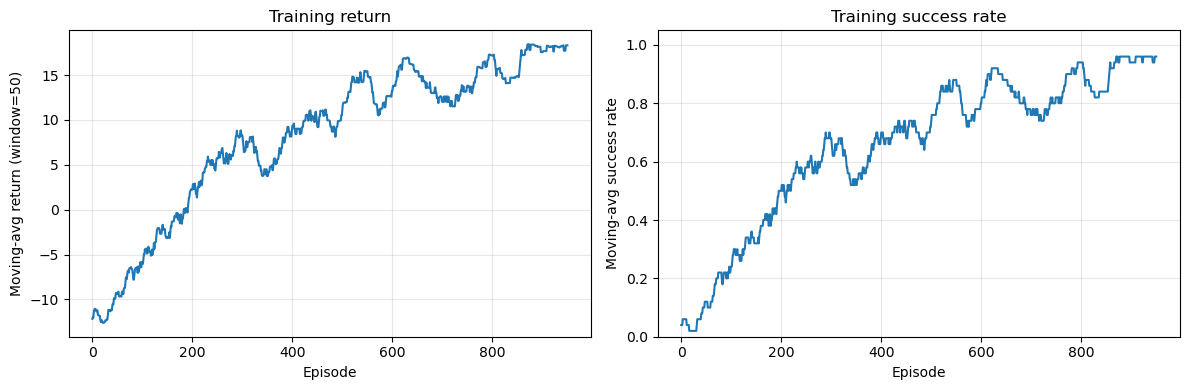

Final 100-ep success rate : 0.95
Final 100-ep avg return   : 17.94


In [15]:
def moving_average(x, window=50):
    x = np.asarray(x, dtype=np.float32)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(moving_average(rewards, 50))
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Moving-avg return (window=50)")
axes[0].set_title("Training return")
axes[0].grid(alpha=0.3)

axes[1].plot(moving_average(successes, 50))
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Moving-avg success rate")
axes[1].set_title("Training success rate")
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final 100-ep success rate : {np.mean(successes[-100:]):.2f}")
print(f"Final 100-ep avg return   : {np.mean(rewards[-100:]):.2f}")


In [16]:
# Run

In [18]:
def run_demo(policy_net, seed=123, device="cpu"):
    demo_env = BobaOrderEnv(seed=seed)
    state    = demo_env.reset()

    print("Hidden goal:", demo_env.goal)
    print("=" * 60)

    done         = False
    total_reward = 0.0
    turn_count   = 0

    while not done:
        with torch.no_grad():
            s_t    = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            action = int(policy_net(s_t).argmax(dim=1).item())

        next_state, reward, done, info = demo_env.step(action)
        total_reward += reward
        turn_count   += 1

        print(f"Turn {turn_count} | action: {info['action']}")
        print(f"  Bot : {info['bot']}")
        print(f"  User: {info['user']}")
        print(f"  Reward: {reward:+.1f}  |  Filled so far: {info['filled']}")
        print("-" * 60)

        state = next_state

    print(f"Success: {info['success']}  |  Total reward: {total_reward:.1f}")


run_demo(policy_net)

Hidden goal: {'drink': 'milk tea', 'size': 'medium', 'sugar': '100%', 'ice': 'regular ice', 'name': 'casey'}
Turn 1 | action: request_sugar
  Bot : What sugar would you like?
  User: sugar = 100%
  Reward: +0.0  |  Filled so far: {'drink': None, 'size': None, 'sugar': '100%', 'ice': None, 'name': None}
------------------------------------------------------------
Turn 2 | action: request_name
  Bot : What name would you like?
  User: name = casey
  Reward: +0.0  |  Filled so far: {'drink': None, 'size': None, 'sugar': '100%', 'ice': None, 'name': 'casey'}
------------------------------------------------------------
Turn 3 | action: request_size
  Bot : What size would you like?
  User: size = medium
  Reward: +0.0  |  Filled so far: {'drink': None, 'size': 'medium', 'sugar': '100%', 'ice': None, 'name': 'casey'}
------------------------------------------------------------
Turn 4 | action: request_ice
  Bot : What ice would you like?
  User: ice = regular ice
  Reward: +0.0  |  Filled so

## Save

In [ ]:
# torch.save(policy_net.state_dict(), "boba_dqn_chatbot.pt")
# print("Saved to boba_dqn_chatbot.pt")